Gambaran Umum:

# VISUALISASI SAHAM 
## Stock Visualization 

##### Import Library

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly_express as px
import numpy as np

##### Downloading Tickers Data and Set the Range Date of Data

In [18]:
import datetime
import yfinance as yf

tickers = ['INCO.JK', 'SMGR.JK', 'ICBP.JK', 'BRPT.JK', 'MNCN.JK']

end_date = datetime.datetime(year=2025, month=12, day=8)
start_date = end_date - datetime.timedelta(days=5 * 365)

stock = pd.DataFrame()

for ticker in tickers:
    try:
        data = yf.download(
            ticker,
            start=start_date,
            end=end_date,
            progress=False
        )

        if data.empty:
            print(f"[INFO] Tidak ada data untuk {ticker}")
            continue
        
        price_col = 'Adj Close' if 'Adj Close' in data.columns else 'Close'

        if price_col not in data.columns:
            print(f"[WARN] Kolom harga tidak ditemukan untuk {ticker}")
            continue

        if price_col == 'Close':
            print(f"[WARN] 'Adj Close' tidak tersedia, memakai 'Close' untuk {ticker}")

        stock[ticker] = data[price_col]

    except Exception as e:
        print(f"[ERROR] Gagal mengambil data {ticker}: {e}")

print(stock.head())



[WARN] 'Adj Close' tidak tersedia, memakai 'Close' untuk INCO.JK
[WARN] 'Adj Close' tidak tersedia, memakai 'Close' untuk SMGR.JK
[WARN] 'Adj Close' tidak tersedia, memakai 'Close' untuk ICBP.JK
[WARN] 'Adj Close' tidak tersedia, memakai 'Close' untuk BRPT.JK
[WARN] 'Adj Close' tidak tersedia, memakai 'Close' untuk MNCN.JK
                INCO.JK       SMGR.JK      ICBP.JK      BRPT.JK      MNCN.JK
Date                                                                        
2020-12-10  4840.527832  10110.306641  8914.843750  1176.332642  1032.527100
2020-12-11  5033.185547   9915.878906  8802.848633  1210.785889  1027.610352
2020-12-14  5081.350098  10369.545898  8802.848633  1225.551636  1042.360596
2020-12-15  5057.268066  10585.579102  8690.854492  1230.473511  1037.443970
2020-12-16  5298.090332  10888.023438  8758.051758  1240.317383  1175.114136


##### Visualize Historical Data 5 Ticker

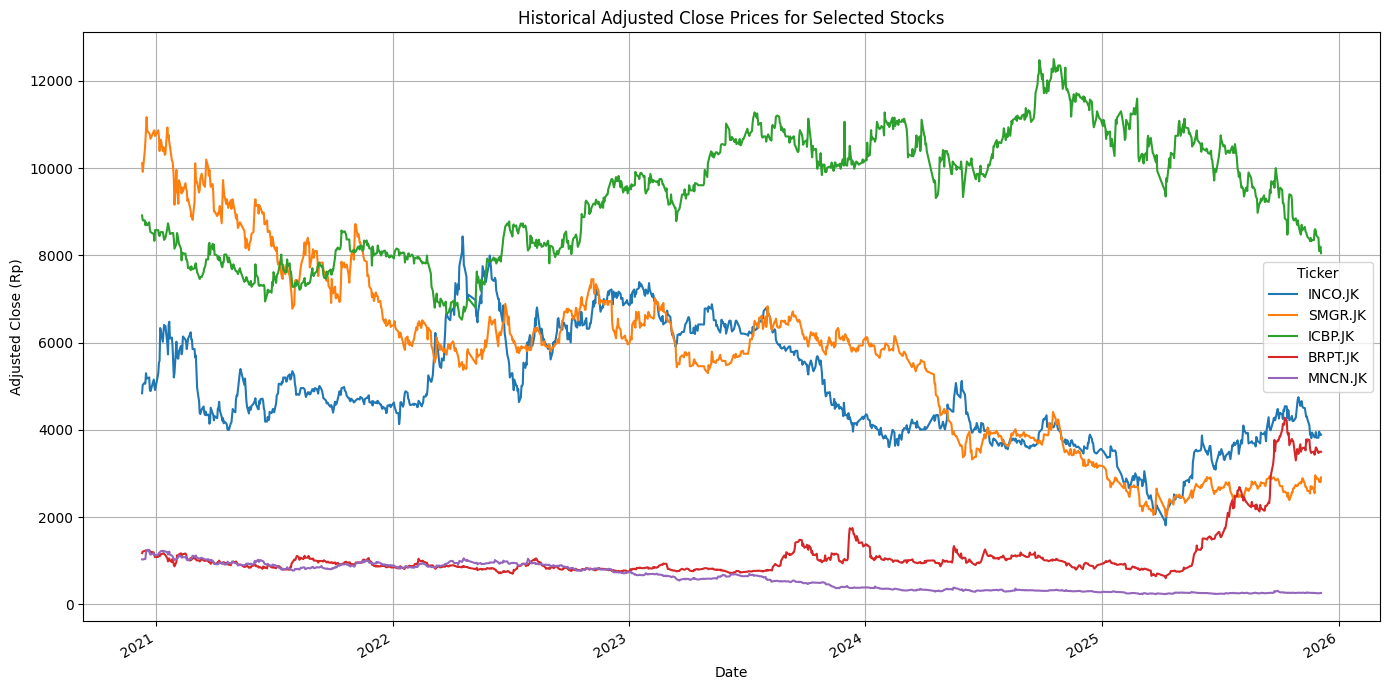

In [19]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 7))

ax = plt.gca()
stock.plot(ax=ax)

ax.set_title('Historical Adjusted Close Prices for Selected Stocks')
ax.set_xlabel('Date')
ax.set_ylabel('Adjusted Close (Rp)')
ax.legend(title='Ticker')
ax.grid(True)
plt.tight_layout()
plt.show()



##### Stock Info, Statistic and Null Checking

In [20]:
print("Informasi Ringkas DataFrame stock:")
stock.info()

print("\nStatistik Deskriptif DataFrame stock:")
print(stock.describe())

print("\nJumlah Nilai Hilang per Kolom di stock:")
print(stock.isnull().sum())

Informasi Ringkas DataFrame stock:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1203 entries, 2020-12-10 to 2025-12-05
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   INCO.JK  1203 non-null   float64
 1   SMGR.JK  1203 non-null   float64
 2   ICBP.JK  1203 non-null   float64
 3   BRPT.JK  1203 non-null   float64
 4   MNCN.JK  1203 non-null   float64
dtypes: float64(5)
memory usage: 56.4 KB

Statistik Deskriptif DataFrame stock:
           INCO.JK       SMGR.JK       ICBP.JK      BRPT.JK      MNCN.JK
count  1203.000000   1203.000000   1203.000000  1203.000000  1203.000000
mean   4926.864119   5667.946868   9380.406779  1134.363096   612.297069
std    1282.956739   2116.737862   1377.137715   645.710334   291.847396
min    1812.706665   2017.924805   6525.929688   600.000000   232.000000
25%    3980.073242   3775.160645   8134.434082   828.562714   316.000000
50%    4637.289551   5918.951172   9550.000000   946.6271

##### Stock convert to daily return, monthly returns and normalized stock data

In [21]:
import pandas as pd

daily_returns = stock.pct_change().dropna()

monthly_returns = (
    stock.resample('ME').last()
         .pct_change()
         .dropna()
)

normalized_stock_data = stock / stock.iloc[0]

print("\n=== Lima Baris Pertama Daily Returns ===")
print(daily_returns.head())

print("\n=== Lima Baris Pertama Monthly Returns ===")
print(monthly_returns.head())

print("\n=== Lima Baris Pertama Normalized Stock Data ===")
print(normalized_stock_data.head())



=== Lima Baris Pertama Daily Returns ===
             INCO.JK   SMGR.JK   ICBP.JK   BRPT.JK   MNCN.JK
Date                                                        
2020-12-11  0.039801 -0.019231 -0.012563  0.029289 -0.004762
2020-12-14  0.009569  0.045752  0.000000  0.012195  0.014354
2020-12-15 -0.004739  0.020833 -0.012722  0.004016 -0.004717
2020-12-16  0.047619  0.028571  0.007732  0.008000  0.132701
2020-12-17 -0.018182  0.025794 -0.005115  0.000000  0.054393

=== Lima Baris Pertama Monthly Returns ===
             INCO.JK   SMGR.JK   ICBP.JK   BRPT.JK   MNCN.JK
Date                                                        
2021-01-31  0.078431 -0.146881 -0.049608 -0.195455 -0.092105
2021-02-28  0.104545 -0.037736 -0.057692  0.242938  0.096618
2021-03-31 -0.279012  0.022059  0.072886 -0.127273 -0.158590
2021-04-30  0.052511  0.018530 -0.054348  0.041667  0.026178
2021-05-31  0.035498 -0.069544 -0.057471 -0.097205 -0.056122

=== Lima Baris Pertama Normalized Stock Data ===
          

##### Histogram and Boxplot about Daily Returns distribution

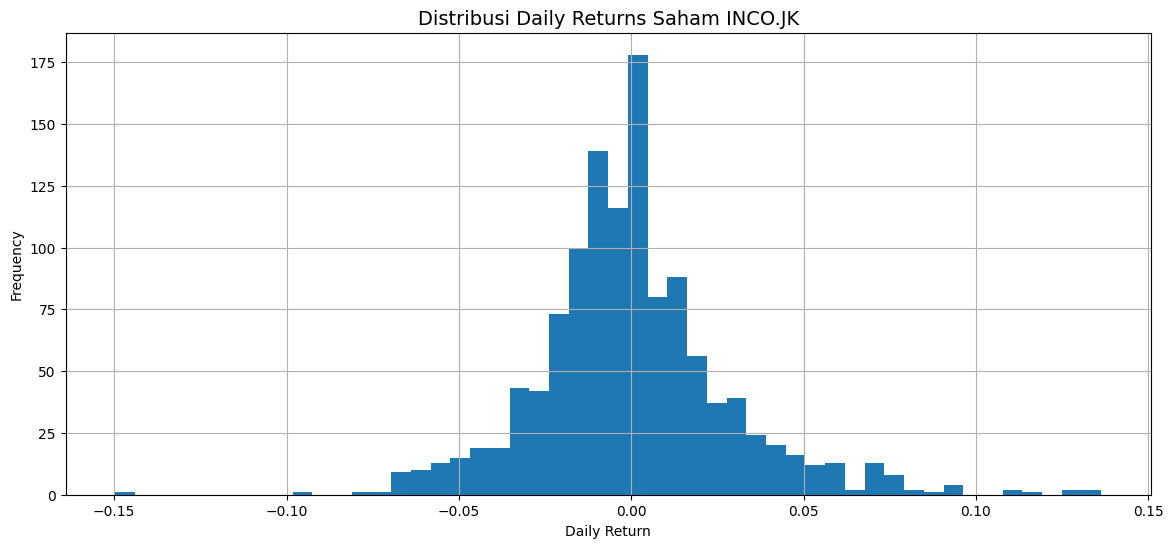

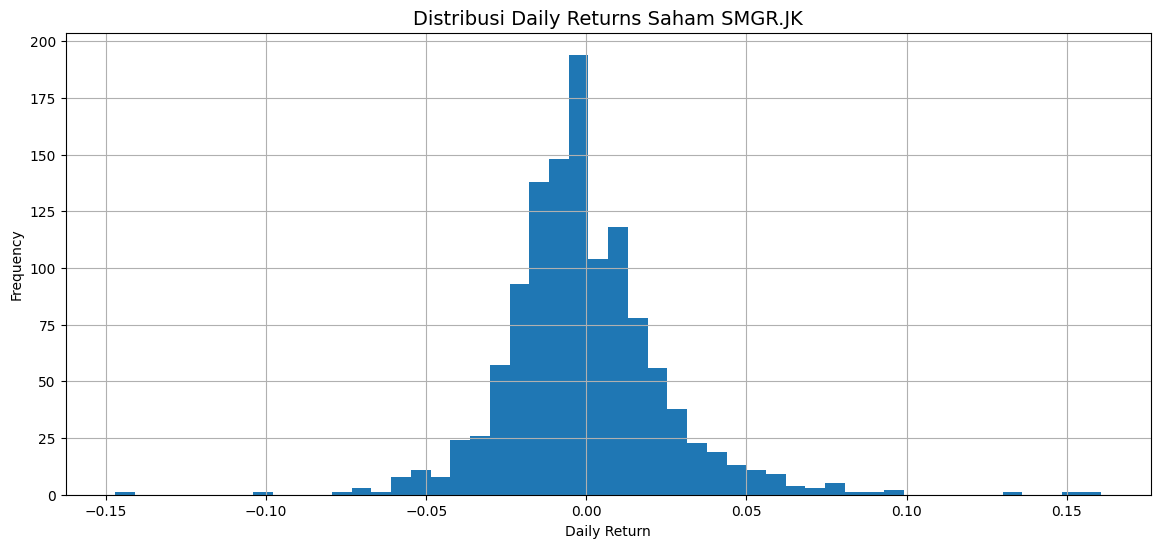

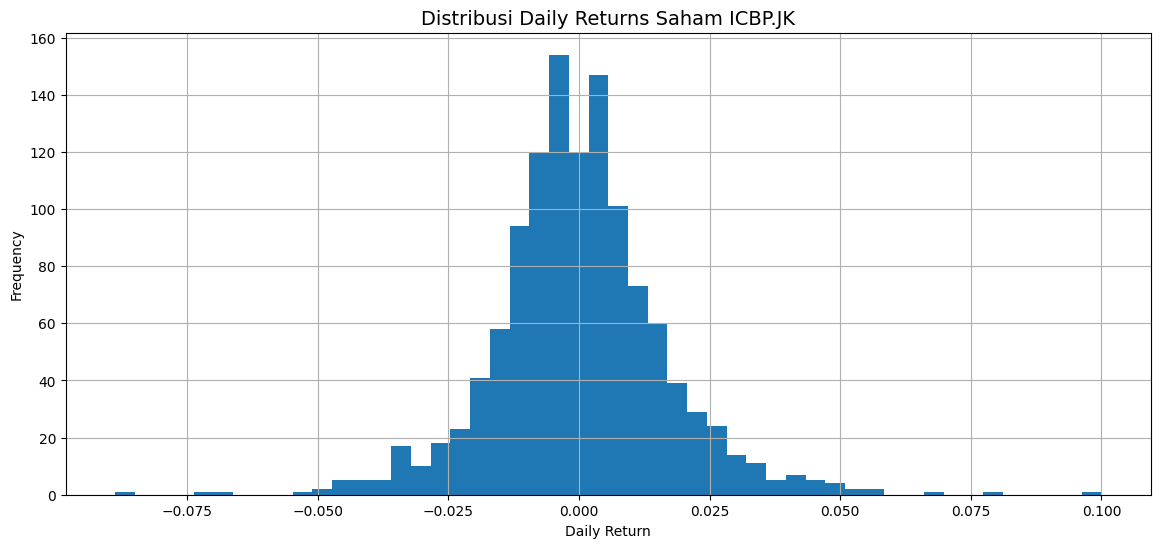

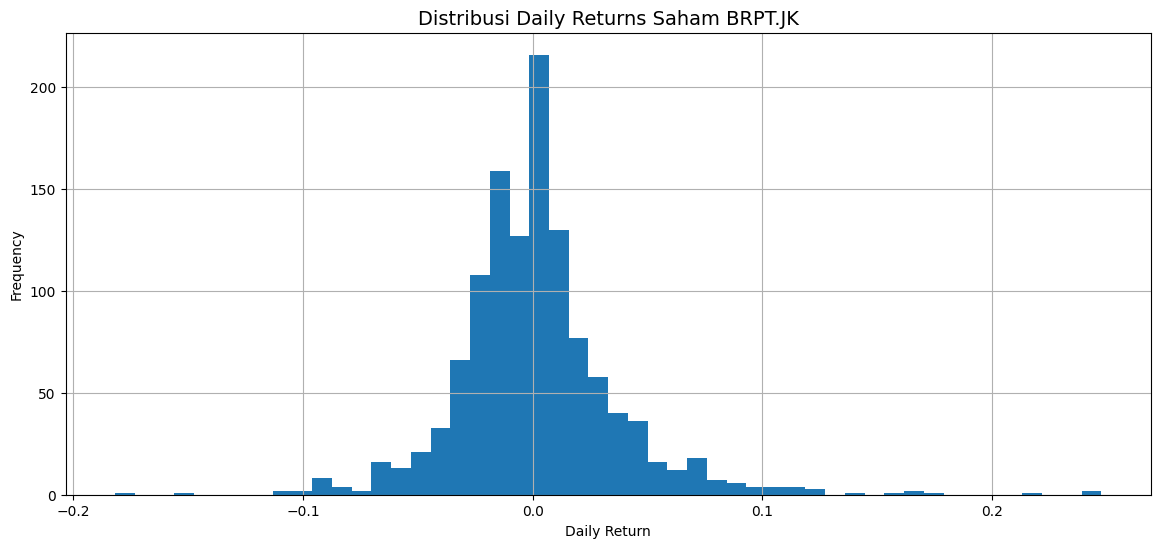

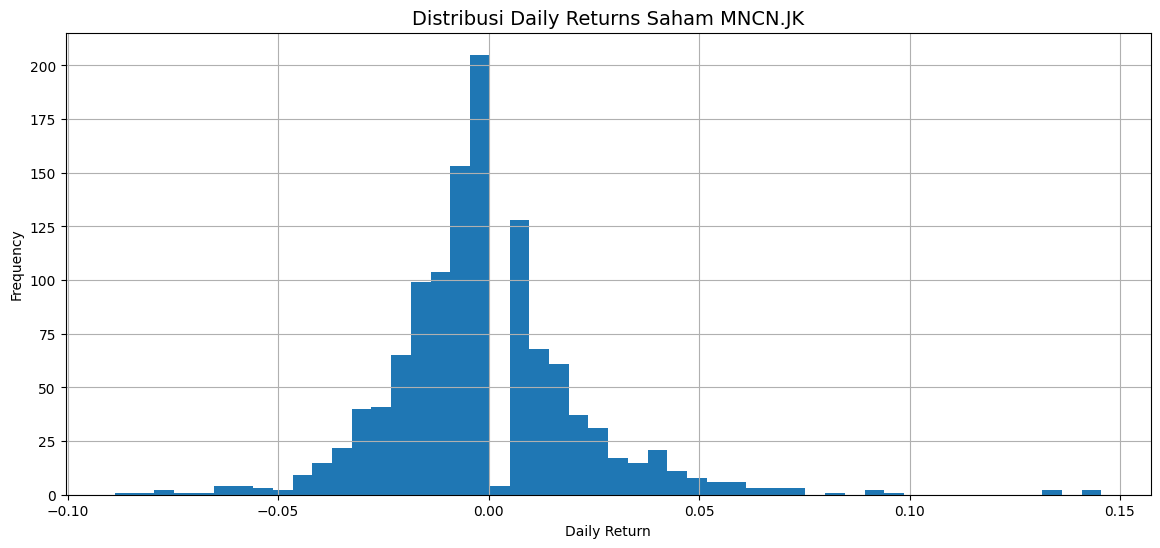

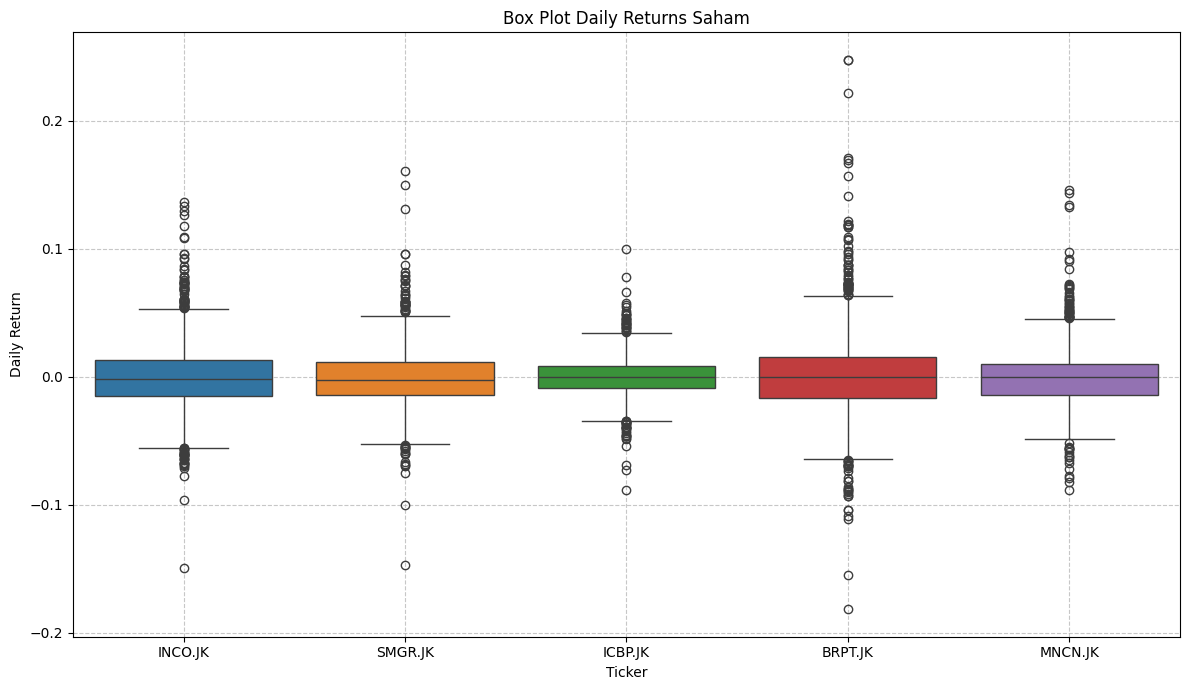

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

for column in daily_returns.columns:
    
    fig, ax = plt.subplots(figsize=(14, 6)) 

    daily_returns[column].hist(bins=50, ax=ax)

    ax.set_title(f'Distribusi Daily Returns Saham {column}', fontsize=14)
    ax.set_xlabel('Daily Return')
    ax.set_ylabel('Frequency')
    
    plt.show() 

plt.figure(figsize=(12, 7))
plt.title('Box Plot Daily Returns Saham')
sns.boxplot(data=daily_returns)
plt.xlabel('Ticker')
plt.ylabel('Daily Return')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### Interactive Line Plot and Histogram for Stock Normalize ratio

In [23]:
import plotly_express as px

fig_normalized_prices = px.line(
    normalized_stock_data,
    x=normalized_stock_data.index,
    y=normalized_stock_data.columns,
    title='Perbandingan Harga Saham yang Dinormalisasi (Interaktif)',
    labels={'index': 'Tanggal', 'value': 'Harga Dinormalisasi'},
    hover_name=normalized_stock_data.columns.name 
)

fig_normalized_prices.update_layout(
    xaxis_title='Tanggal',
    yaxis_title='Harga Dinormalisasi'
)

fig_normalized_prices.show()

##### Portofolio Metrics

In [24]:
import datetime
TRADING_DAYS_PER_YEAR = 252
RISK_FREE_RATE = 0.01

cumulative_returns = (1 + daily_returns).prod() - 1

annual_returns = daily_returns.mean() * TRADING_DAYS_PER_YEAR

annualized_volatility = daily_returns.std() * np.sqrt(TRADING_DAYS_PER_YEAR)

sharpe_ratios = (annual_returns - RISK_FREE_RATE) / annualized_volatility

portfolio_metrics = pd.DataFrame({
    'Cumulative Return': cumulative_returns,
    'Annual Return': annual_returns,
    'Annualized Volatility': annualized_volatility,
    'Sharpe Ratio': sharpe_ratios
})

print("Metrik Portofolio untuk Setiap Saham:")
print(portfolio_metrics.round(4))

Metrik Portofolio untuk Setiap Saham:
         Cumulative Return  Annual Return  Annualized Volatility  Sharpe Ratio
INCO.JK            -0.1964         0.0548                 0.4511        0.0994
SMGR.JK            -0.7122        -0.1870                 0.3866       -0.5095
ICBP.JK            -0.0970         0.0127                 0.2616        0.0105
BRPT.JK             1.9753         0.3888                 0.5726        0.6615
MNCN.JK            -0.7463        -0.2196                 0.3706       -0.6196


##### Combined Metrics

In [25]:
import numpy as np

num_assets = len(tickers)
weights = np.array([1/num_assets] * num_assets)

weights_df = pd.Series(weights, index=daily_returns.columns)

portfolio_daily_returns = daily_returns.dot(weights)

print("Lima Baris Pertama Daily Returns Portofolio:")
print(portfolio_daily_returns.head())

Lima Baris Pertama Daily Returns Portofolio:
Date
2020-12-11    0.006507
2020-12-14    0.016374
2020-12-15    0.000534
2020-12-16    0.044925
2020-12-17    0.011378
dtype: float64


In [26]:
import numpy as np

portfolio_cumulative_return = (1 + portfolio_daily_returns).prod() - 1

portfolio_annual_return = portfolio_daily_returns.mean() * TRADING_DAYS_PER_YEAR

portfolio_annualized_volatility = portfolio_daily_returns.std() * np.sqrt(TRADING_DAYS_PER_YEAR)

portfolio_sharpe_ratio = (portfolio_annual_return - RISK_FREE_RATE) / portfolio_annualized_volatility

print("\nMetrik Keseluruhan Portofolio (Bobot Sama):")
print(f"Cumulative Return: {portfolio_cumulative_return:.4f}")
print(f"Annual Return: {portfolio_annual_return:.4f}")
print(f"Annualized Volatility: {portfolio_annualized_volatility:.4f}")
print(f"Sharpe Ratio: {portfolio_sharpe_ratio:.4f}")


Metrik Keseluruhan Portofolio (Bobot Sama):
Cumulative Return: -0.0828
Annual Return: 0.0100
Annualized Volatility: 0.2372
Sharpe Ratio: -0.0002


##### Monte Carlo Simulation

In [37]:
import numpy as np
import pandas as pd

np.random.seed(42)

num_portfolios = 10000

portfolio_returns = []
portfolio_volatility = []
portfolio_sharpe_ratios = []
portfolio_weights = []

num_assets = len(daily_returns.columns)
mean_daily_returns = daily_returns.mean()
cov_matrix_daily = daily_returns.cov()

for portfolio in range(num_portfolios):
    weights = np.random.random(num_assets)
    weights = weights / np.sum(weights)

    portfolio_weights.append(weights)

    annual_returns_individual = mean_daily_returns * TRADING_DAYS_PER_YEAR
    portfolio_annual_return = np.sum(annual_returns_individual * weights)
    portfolio_returns.append(portfolio_annual_return)

    portfolio_annual_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix_daily * TRADING_DAYS_PER_YEAR, weights)))
    portfolio_volatility.append(portfolio_annual_volatility)

    sharpe_ratio = (portfolio_annual_return - RISK_FREE_RATE) / portfolio_annual_volatility
    portfolio_sharpe_ratios.append(sharpe_ratio)

portfolio_results = pd.DataFrame({
    'Return': portfolio_returns,
    'Volatility': portfolio_volatility,
    'Sharpe Ratio': portfolio_sharpe_ratios
})

for i, col in enumerate(daily_returns.columns):
    portfolio_results[col + ' Weight'] = [w[i] for w in portfolio_weights]

print("Lima baris pertama hasil simulasi portofolio:")
print(portfolio_results.head())

optimal_portfolio = portfolio_results.loc[portfolio_results['Sharpe Ratio'].idxmax()]
min_volatility_portfolio = portfolio_metrics.loc[portfolio_metrics['Annualized Volatility'].idxmin()]

print("\n======================================================")
print("Portofolio Optimal (Sharpe Ratio Tertinggi):")
print("------------------------------------------------------")
print(f"Annual Return: {optimal_portfolio['Return']:.4f}")
print(f"Annualized Volatility: {optimal_portfolio['Volatility']:.4f}")
print(f"Sharpe Ratio: {optimal_portfolio['Sharpe Ratio']:.4f}")
print("Weights:")
for col in daily_returns.columns:
    print(f"  {col}: {optimal_portfolio[col + ' Weight']:.4f}")
print("======================================================")

print("\n======================================================")
print("Portofolio Risiko Minimum:")
print("------------------------------------------------------")
print(f"Annual Return: {min_volatility_portfolio['Annual Return']:.4f}")
print(f"Annualized Volatility: {min_volatility_portfolio['Annualized Volatility']:.4f}")
print(f"Sharpe Ratio: {min_volatility_portfolio['Sharpe Ratio']:.4f}")
print("Weights:")
for col in daily_returns.columns:
    print(f"  {col}: {min_volatility_portfolio[col + ' Weight']:.4f}")
print("======================================================")

Lima baris pertama hasil simulasi portofolio:
     Return  Volatility  Sharpe Ratio  INCO.JK Weight  SMGR.JK Weight  \
0  0.017997    0.242743      0.032945        0.133197        0.338101   
1  0.036384    0.238588      0.110584        0.065285        0.024308   
2 -0.057273    0.238557     -0.281999        0.009284        0.437468   
3  0.036784    0.235526      0.113719        0.105673        0.175297   
4  0.028654    0.255146      0.073111        0.327909        0.074759   

   ICBP.JK Weight  BRPT.JK Weight  MNCN.JK Weight  
0        0.260318        0.212900        0.055485  
1        0.362501        0.251571        0.296334  
2        0.375464        0.095773        0.082010  
3        0.302353        0.248877        0.167800  
4        0.156568        0.196343        0.244421  

Portofolio Optimal (Sharpe Ratio Tertinggi):
------------------------------------------------------
Annual Return: 0.2745
Annualized Volatility: 0.4200
Sharpe Ratio: 0.6299
Weights:
  INCO.JK: 0.1580
  

KeyError: 'INCO.JK Weight'

##### Efficient Frontier from Monte Carlo Simulation

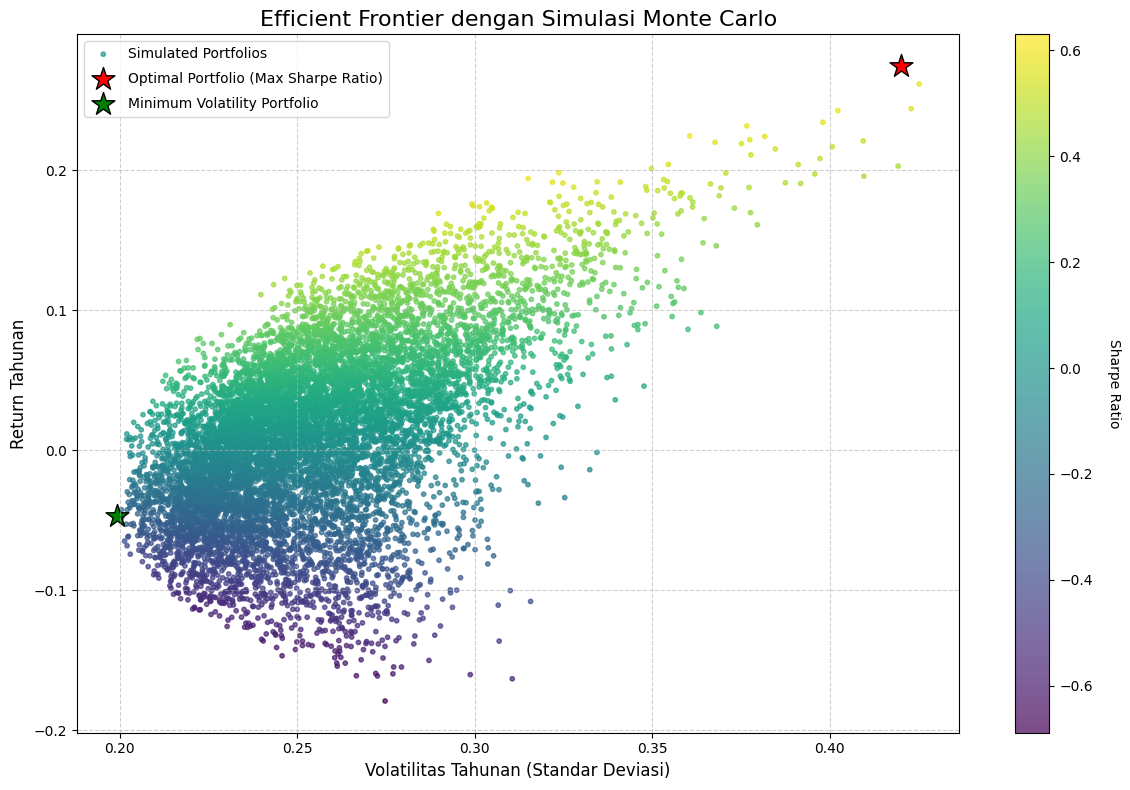

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    portfolio_results['Volatility'],
    portfolio_results['Return'],
    c=portfolio_results['Sharpe Ratio'], 
    cmap='viridis',
    marker='o',
    s=10,
    alpha=0.7,
    label='Simulated Portfolios'
)

plt.scatter(
    optimal_portfolio['Volatility'],
    optimal_portfolio['Return'],
    marker='*',  
    color='red',
    s=300,
    label='Optimal Portfolio (Max Sharpe Ratio)',
    edgecolors='black',
    linewidth=1
)

plt.scatter(
    min_volatility_portfolio['Volatility'],
    min_volatility_portfolio['Return'],
    marker='*', 
    color='green',
    s=300,
    label='Minimum Volatility Portfolio',
    edgecolors='black',
    linewidth=1
)

plt.title('Efficient Frontier dengan Simulasi Monte Carlo', fontsize=16)
plt.xlabel('Volatilitas Tahunan (Standar Deviasi)', fontsize=12)
plt.ylabel('Return Tahunan', fontsize=12)

plt.legend(labelspacing=0.8, loc='best')
plt.grid(True, linestyle='--', alpha=0.6)

cbar = plt.colorbar(scatter)
cbar.set_label('Sharpe Ratio', rotation=270, labelpad=20)

plt.tight_layout()
plt.show()